<a href="https://colab.research.google.com/github/ColinaAndres/Heart-Disease-Prediction/blob/main/notebooks/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports y Google Drive autenticacion

In [ ]:
import plotly.express as px
import plotly.figure_factory as ff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install feature_engine
from feature_engine.encoding import MeanEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 4.5 MB/s eta 0:00:00


In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id = '1QHrv5jOfyW6znzSvY8U4eGgLsAWa_Ln0'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('heart_train.csv')

In [ ]:
id_test = '1ToTRlYQqwxhNn48T5JvIoEFxCxDmZRpR'
downloaded_test = drive.CreateFile({'id': id_test})
downloaded_test.GetContentFile('heart_test.csv')

# Carga del Dataset

In [ ]:
heart_data = pd.read_csv('heart_train.csv',encoding='latin1')
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1


In [ ]:
test_data = pd.read_csv('heart_test.csv',encoding='latin1')

# Proceso de Matchine Learning

## Division train y validation

In [ ]:
x = heart_data.drop('HeartDisease', axis=1)
y = heart_data['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_validation, y_train, y_validation = train_test_split(x, y, test_size=0.2, random_state=37)

## Preprocesamiento

In [ ]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
original_cols_ordenr = x_train.columns.tolist()

Mean Encoding

In [ ]:
encoder = MeanEncoder(variables=cat_cols, smoothing='auto', unseen='encode')
encoder.fit(x_train, y_train)
x_train = encoder.transform(x_train)
x_validation = encoder.transform(x_validation)
test_data_final = encoder.transform(test_data)

Escalado

In [ ]:
from sklearn.preprocessing import StandardScaler

escaler = StandardScaler()
x_train = escaler.fit_transform(x_train)
x_validation = escaler.transform(x_validation)
test_data_final = escaler.transform(test_data_final)

Rearmado de Dataframe

In [ ]:
x_train = pd.DataFrame(x_train, columns=original_cols_ordenr)
x_validation = pd.DataFrame(x_validation, columns=original_cols_ordenr)
test_data_final = pd.DataFrame(test_data_final, columns=original_cols_ordenr)

## Busqueda de HiperParametros

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

* **learning_rate:** tasa de aprendizaje, es decir, controla cuanto ajustar en cada iteracion. Valores bajos implican una mayor cantidad de iteraciones.
* **max_depth:** máxima profundidad de cada árbol, a mayor profundidad aumenta la complejidad.
* **subsample:** porcentaje de muestras usadas para cada árbol (valor muy bajo, posible underfitting)
* **colsample_bytree:** porcentaje de features usadas para cada árbol (valores muy alto, posible overfitting)
* **n_estimators:** cantidad de árboles a construir (más árboles puede mejorar precisión, pero aumenta riesgo de overfitting).
* **objective:** función de error a utilizar.

Parámetros de regularización:

* **gamma:** umbral para hacer split basado en la reducción de error de hacer el nuevo split.
* **alpha:** regularización para los pesos de las hojas. Un valor más alto genera una mayor regularización.
* **lambda:** similar alpha pero para la sintonia fina.

In [ ]:
xgb_mod = xgb.XGBClassifier()

In [ ]:
parametros_xgb = {
    'learning_rate': [0.08, 0.09, 0.1, 0.11, 0.12],
    'max_depth':  [7, 8, 9],
    'subsample': [0.7, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.75, 0.8, 0.85],
    'n_estimators': [40, 45, 50],
    'gamma': [0.25, 0.3, 0.31],
    'alpha': [1.2, 1.5, 1.8],
    'lambda': [0.1, 0.2, 0.3],
    'objective': ['binary:logistic', 'reg:logistic']
}

In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_mod,
    param_distributions=parametros_xgb,
    n_iter=10,
    scoring='roc_auc',
    cv=4,
    verbose=2,
    random_state=4,
    n_jobs=-1
)

In [ ]:
random_search_xgb.fit(x_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


RandomizedSearchCV(cv=4,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   n_jobs=-1,
                   param_distributions={'alpha': [1.2, 1.5, 1.8],
                                        'colsample_bytree': [0.6, 0.7, 0.75,
                                                             0.8, 0.85],
                                        'gamma': [0.25, 0.3, 0.31],
                                        'lambda': [0.1, 0.2, 0.3],
                                        'learning_rate': [0.08, 0.09, 0.1, 0.11,
                                                          0.12],
                                        'max_depth': [7, 8, 9],
                                        'n_estimators': [40, 45, 50],
                                        'objective': ['binary:logistic',
                                                      'reg:logistic'],
                                        'subsample': [0.7, 0.8, 0.85, 0.9]},
                   random_state=4, scoring='roc_auc', verbose=2)

In [ ]:
random_search_xgb.best_params_

{'subsample': 0.8,
 'objective': 'binary:logistic',
 'n_estimators': 40,
 'max_depth': 9,
 'learning_rate': 0.11,
 'lambda': 0.3,
 'gamma': 0.31,
 'colsample_bytree': 0.8,
 'alpha': 1.5}

In [ ]:
model = random_search_xgb.best_estimator_

In [ ]:
model.fit(x_train, y_train)

XGBClassifier(alpha=1.5, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.31, grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=0.3, learning_rate=0.11,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=40, n_jobs=None, ...)

## Evaluacion del modelo

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
y_predicted = model.predict(x_validation)

In [ ]:
y_validation = y_validation.astype(int)

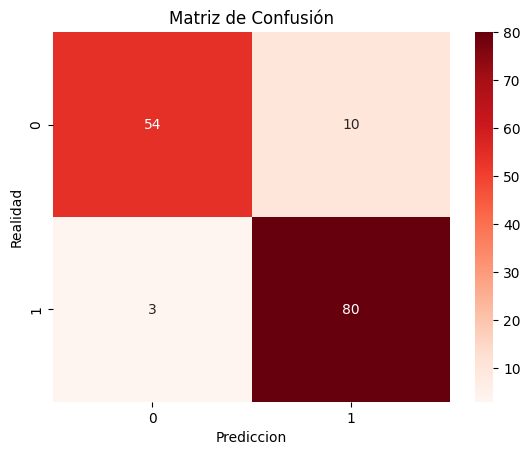

In [ ]:
cm = confusion_matrix(y_validation, y_predicted)
sns.heatmap(cm, annot=True, cmap='Reds')
plt.title('Matriz de Confusión')
plt.xlabel('Prediccion')
plt.ylabel('Realidad')
plt.show()

In [ ]:
accuracy_score(y_validation, y_predicted)

0.9115646258503401

In [ ]:
recall_score = cm[1][1] / sum(cm[1])
recall_score

np.float64(0.963855421686747)

In [ ]:
y_predicted = y_predicted.astype(str)
y_validation = y_validation.astype(str)
y_prob = model.predict_proba(x_validation)[:, 1]
roc_auc_score(y_validation, y_prob)

np.float64(0.9553840361445783)

## Features mas importantes

In [ ]:
import plotly.graph_objs as go
importances = model.get_booster().get_score(importance_type='gain')

feat_importance = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
}).sort_values(by='Importance', ascending=True)

fig = go.Figure(go.Bar(
    x=feat_importance['Importance'],
    y=feat_importance['Feature'],
    orientation='h',
    marker=dict(
        color=feat_importance['Importance'],
        colorscale='plasma',
        showscale=True
    )
))

fig.update_layout(
    title='Importancia de Features - XGBoost (Gain)',
    title_font=dict(size=24, family='Arial', color='black'),
    xaxis=dict(
        title='Importancia',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title='Features',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    margin=dict(l=200, r=50, t=70, b=50),
    showlegend=False
)

fig.show()

# Predicion para la competencia

In [ ]:
prediccion = model.predict(test_data_final)

In [ ]:
submission_xgb = pd.DataFrame({
    'id': range(len(prediccion)),
    'HeartDisease': prediccion
})

In [ ]:
submission_xgb.to_csv('submission_xgb.csv', index=False)